In [12]:
import os
import sys
import pandas as pd

# Path to the dataset zip file
data_folder = "./data2"

project_root = os.path.abspath(os.path.join(os.getcwd(), "../../.."))
sys.path.append(project_root)

df_private = pd.read_pickle(os.path.join(data_folder, "private_df.pkl"))

print(df_private.columns)
print(df_private.shape)

Index(['Weight (Lbs)', 'BMI (kg/m2)', 'Height (Inches)', 'num_medications',
       'num_procedures', 'length_of_stay', 'race', 'insurance', 'gender',
       'curr_service_MED', 'curr_service_CMED', '51248', '51249', '50912',
       '51003', '50931', '51006', '51301', '50970', '51265', '51275', '51277',
       'med_Aspirin', '51250', '50882', '50902', '51221',
       'med_Sodium Chloride 0.9%  Flush', '50893', '51279',
       'curr_service_OMED', '52172', '51222', 'curr_service_SURG', '51256',
       'med_Acetaminophen', '50971', '51274', '51237', '50983', '51244',
       'med_Heparin', '50910', '50960', 'curr_service_OBS', 'med_Furosemide',
       'curr_service_NMED', '50868', '51493', '50878', 'identity'],
      dtype='object')
(23792, 51)


In [13]:
import os
import sys
import yaml
import warnings
from pytorch_tabular import TabularModel
from pytorch_tabular.models import CategoryEmbeddingModelConfig, TabNetModelConfig, GANDALFConfig
from pytorch_tabular.config import DataConfig, OptimizerConfig, TrainerConfig
import pandas as pd

# Suppres warnings, pytorch_tabular is very verbose
warnings.filterwarnings("ignore")

# Redefine variables in case upper cell is not run
# Path to the dataset zip file
data_folder = "./data2"

project_root = os.path.abspath(os.path.join(os.getcwd(), "../../.."))
sys.path.append(project_root)

# List of all possible continuous columns in MIMIC
continuous_col_names = ['length_of_stay', 'num_procedures', 'num_medications', 'BMI',
       'BMI (kg/m2)', 'Height', 'Height (Inches)', 'Weight', 'Weight (Lbs)',
       'eGFR', 'systolic', 'diastolic']

# TODO: REMOVE THIS
audit_file = 'audit.yaml'
data_file = '/private_df.pkl'

# Load the config.yaml file
with open('train_config.yaml', 'r') as file:
    train_config = yaml.safe_load(file)

with open(audit_file, 'r') as file:
    audit_config = yaml.safe_load(file)

# Access the first attack in the attack_list
plgmi_attack = next(
    attack for attack in audit_config["audit"]["attack_list"] if attack["attack"] == "plgmi"
)

# Extract num_classes
num_classes = plgmi_attack["num_classes"]

# Generate the dataset and dataloaders
path = os.path.join(os.getcwd(), train_config["data"]["data_dir"])
data_dir =  train_config["data"]["data_dir"] + data_file

df = pd.read_pickle(data_dir)

# Reset index to have a clean, sequential integer index
df = df.reset_index(drop=True)

# Remove the columns from continuous_col_names that are not in the dataframe
continuous_col_names = [col for col in continuous_col_names if col in df.columns]
# Categorical column names are all columns that are not continuous
categorical_col_names = [col for col in df.columns if col not in continuous_col_names]
# Remove the target column
categorical_col_names.remove("identity")

# Ensure df_train contains at least one sample for every class
df_train_min = df.groupby("identity").head(1)  
remaining_df = df.drop(df_train_min.index)

# Determine the fraction for the remaining samples:
desired_frac = train_config["data"]["f_train"]
frac_remaining = desired_frac - (len(df_train_min) / len(df))
df_train_remaining = remaining_df.sample(frac=frac_remaining, random_state=123)

# Merge the guaranteed and random samples.
# Note: we keep the original indices here (do not use ignore_index) so that we can compute df_val correctly.
train_indices = df_train_min.index.union(df_train_remaining.index)
df_train = df.loc[train_indices]

# Create df_val by taking the rest of the samples
df_test = df.drop(train_indices)
df_test = df_test[df_test["identity"].isin(df_train["identity"])]
df_test = df_test.reset_index(drop=True)

# Prints
print("Number of unique classes in df_train: ", df_train["identity"].nunique())
print("Shape of df_train: ", df_train.shape)
print("Shape of df_test: ", df_test.shape)

Number of unique classes in df_train:  70
Shape of df_train:  (18978, 51)
Shape of df_test:  (4814, 51)


In [4]:
data_config = DataConfig(
    target=['identity'],
    continuous_cols=continuous_col_names,
    categorical_cols=categorical_col_names,
    normalize_continuous_features=False,
)
#--- rest of your config and model setup ---
trainer_config = TrainerConfig(
    auto_lr_find=False,
    batch_size=256,
    max_epochs=1,
    early_stopping="train_loss_0",
    checkpoints=None,
)

optimizer_config = OptimizerConfig()
model_config = GANDALFConfig(
    task="classification",
    gflu_stages=16,
    gflu_dropout=0.1,
    embedding_dropout=0.1,
    learning_rate=1e-3,
)

tabular_model = TabularModel(
    data_config=data_config,
    model_config=model_config,
    optimizer_config=optimizer_config,
    trainer_config=trainer_config,
)

tabular_model.fit(train=df_train, cache_data="none")
# results = tabular_model.evaluate(df_test)
# pred_df = tabular_model.predict(df_test.drop(columns=["identity"]))

2025-09-16 07:25:43,608 - {pytorch_tabular.tabular_model:146} - INFO - Experiment Tracking is turned off

Seed set to 42


2025-09-16 07:25:43,626 - {pytorch_tabular.tabular_model:548} - INFO - Preparing the DataLoaders

2025-09-16 07:25:43,646 - {pytorch_tabular.tabular_datamodule:522} - INFO - Setting up the datamodule for          
classification task

2025-09-16 07:25:43,785 - {pytorch_tabular.tabular_model:599} - INFO - Preparing the Model: GANDALFModel

...

Trainable params: 1.2 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.2 M                                                                                                
Total estimated model params size (MB): 4                                                                          
Modules in train mode: 92                                                                                          
Modules in eval mode: 0

Output()

`Trainer.fit` stopped: `max_epochs=1` reached.


2025-09-16 07:25:48,505 - {pytorch_tabular.tabular_model:689} - INFO - Training the model completed

2025-09-16 07:25:48,506 - {pytorch_tabular.tabular_model:1539} - WARNING - No best model available to load.        
Checkpoint Callback needs to be enabled for this to work

# Plot training/val loss

Available metrics: ['hp_metric', 'valid_loss_0', 'valid_loss', 'valid_accuracy', 'epoch', 'train_loss_0', 'train_accuracy', 'train_loss', 'test_loss_0', 'test_loss', 'test_accuracy']
Test accuracy:  0.43291082978248596


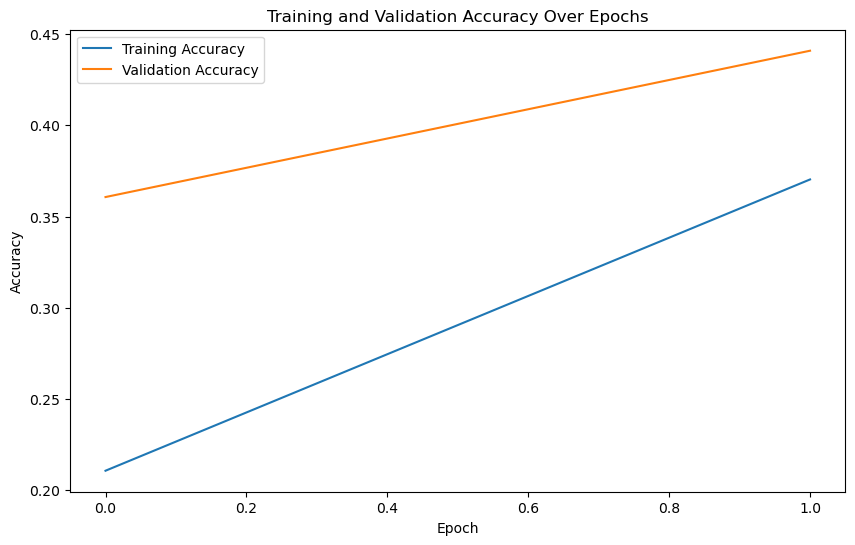

In [14]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import matplotlib.pyplot as plt

# Point to correct log directory here. After training, make sure to save (rename and perhaps move to other folder) the most recent log directory in lightning_logs if you want to keep it.
# OBS: It is possible to use automatically infer specific version from trainer, however I found this behaviour to be inconsistent.
log_dir = "lightning_logs/version_0/"
# Path to the TensorBoard log directory
event_file = f"{log_dir}/events.out.tfevents.*"

# Load the event file
event_acc = EventAccumulator(log_dir)
event_acc.Reload()

# List all available scalar metrics
print("Available metrics:", event_acc.Tags()["scalars"])
# Extract training and validation loss
train_acc = [scalar.value for scalar in event_acc.Scalars("train_accuracy")]
val_acc = [scalar.value for scalar in event_acc.Scalars("valid_accuracy")]
test_acc = [scalar.value for scalar in event_acc.Scalars("test_accuracy")]

print("Test accuracy: ", test_acc[0])

# Plot the metrics
plt.figure(figsize=(10, 6))
plt.plot(train_acc, label="Training Accuracy")
plt.plot(val_acc, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy Over Epochs")
plt.legend()
plt.show()


# Attack

In [15]:
import os
import sys
import warnings

# Suppres warnings, pytorch_tabular is very verbose
warnings.filterwarnings("ignore")
project_root = os.path.abspath(os.path.join(os.getcwd(), "../../.."))
sys.path.insert(0,project_root)

from leakpro import LeakPro
from examples.minv.mimic.mimic_plgmi_handler import Mimic_InputHandler
config_path = "audit.yaml"

# Initialize the LeakPro object
leakpro = LeakPro(Mimic_InputHandler, config_path)

# Run the audit
results = leakpro.run_audit()

2025-09-16 11:34:26,782 INFO     Target model blueprint created from TabularWrapper in ./utils/tabular_wrapper.py.
2025-09-16 11:34:26,784 INFO     Model type is pytorch_tabular, skipping loading metadata.


2025-09-16 11:34:27,841 - {pytorch_tabular.tabular_model:171} - INFO - Experiment Tracking is turned off

2025-09-16 11:34:27,850 - {pytorch_tabular.tabular_model:342} - INFO - Preparing the Trainer

Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.rich_model_summary.RichModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
2025-09-16 11:34:27,877 INFO     Loaded target model from ./target
2025-09-16 11:34:27,885 INFO     Loaded public data from ./data2/public_df.pkl
2025-09-16 11:34:27,889 INFO     Loaded private data from ./data2/private_df.pkl
2025-09-16 11:34:27,890 INFO     Image extension initialized.
2025-09-16 11:34:29,249 INFO     MINV attack factory loaded.
2025-09-16 11:34:29,251 INFO     Configuring PLG-MI attack
2025-09-16 11:34:29,252 INFO     Added attack: plgmi
2025-09-16 11:34:29,253 INFO     Preparing attack: plgmi
2025-09-16 11:34:29,254 INFO     Preparing attack
2025-09-16 11:34:29,254 INFO     Initializing GANHandler...
2025-09-16 11:34:29,255 INFO     Setting up generator configurations


Before backward: None
Before backward: None
Before backward: None
Before backward: None
Before backward: None
Before backward: None
Before backward: None
Before backward: None
Before backward: None
Before backward: None
Before backward: None
Before backward: None
Before backward: None
Before backward: None
Before backward: None
Before backward: None
Before backward: None
Before backward: None
Before backward: None
Before backward: None
Before backward: None
Before backward: None
Before backward: None
Before backward: None
Before backward: None
Before backward: None
Before backward: None
Before backward: None
Before backward: None
Before backward: None
Before backward: None
Before backward: None
Before backward: None
Before backward: None
Before backward: None
Before backward: None
Before backward: None
Before backward: None
Before backward: None
Before backward: None
Before backward: None
Before backward: None
Before backward: None
Before backward: None
Before backward: None
Before bac

...

2025-09-16 11:34:53,569 - {pytorch_tabular.tabular_model:171} - INFO - Experiment Tracking is turned off

2025-09-16 11:34:53,574 - {pytorch_tabular.tabular_model:342} - INFO - Preparing the Trainer

Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.rich_model_summary.RichModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
2025-09-16 11:34:53,598 INFO     Loaded eval model from ./target
2025-09-16 11:34:53,599 INFO     batch_size=4000 num_class_samples=1000 num_audited_classes=20 metrics={'accuracy': None, 'quality_metrics': None, 'plot_densities': None, 'plot_categorical_densities': None} eval_model=EvalModelConfig(model_class='TabularWrapper', module_path='./utils/tabular_wrapper.py', eval_folder='./target')
2025-09-16 11:34:53,640 INFO     Computing accuracy for generated samples.
2025-09-16 11:34:53,648 INFO     Number of runs for accuracy: 1
2025-09-16 11:34:53,648 INFO     Run 1/1 for accuracy.
2025-09-16 11:34:58,782 INFO     Mean accuracy: 0.6822177767753601
2025-09-16 11:34:58,784 INFO     Standard 

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 51/51 [00:00<00:00, 272.52it/s]|
Column Shapes Score: 92.81%

(2/2) Evaluating Column Pair Trends: |██████████| 1275/1275 [00:07<00:00, 176.27it/s]|
Column Pair Trends Score: 83.88%

Overall Score (Average): 88.35%



2025-09-16 11:35:09,979 INFO     Saving results for attack: plgmi to leakpro_output/results
2025-09-16 11:35:09,981 INFO     Auditing completed


In [11]:
import torch

# --- Pick device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

tab = tabular_model           # your trained TabularModel
mdl = tab.model.to(device)              # this is the LightningModule (GANDALFModel)
mdl.eval()                    # eval mode, but NO torch.no_grad()

batch = {}
if x_cont is not None:    batch["continuous"]  = x_cont.to(device).float()
if x_cat_idx is not None: batch["categorical"] = x_cat_idx.to(device).long()

NameError: name 'x_cont' is not defined

In [ ]:
tabular_model.